Cell 1: Setup and Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan
data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(f"DataFrame Shape: {df.shape}")
df.head()

DataFrame Shape: (200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Task 1: Inspect & Handle Missing Values

In [2]:
# 1. Print Shape
print("Shape of DataFrame:", df.shape)

# 2. Display Data Types
print("\nData Types:\n", df.dtypes)

# 3. Count Missing Values
missing_count = df.isnull().sum()
print("\nMissing Values Count:\n", missing_count)

# 4. Calculate Percentage of Missing Values
missing_percentage = (missing_count / len(df)) * 100
print("\nPercentage of Missing Values (%):\n", missing_percentage.round(2))

Shape of DataFrame: (200, 6)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Percentage of Missing Values (%):
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


Task 2: Summarize & Visualize

In [3]:
# Summary Statistics
summary = df.describe()
print(summary)

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


Markdown Observations:
1. Outlier Detection: The order_value column shows a massive gap between the 75th percentile (approx. 3,800) and the maximum value (95,000), indicating the presence of extreme outliers.

2. Average Delivery: The mean for delivery_days is approximately 7.5 days, suggesting a fairly balanced distribution of shipping times within the 1–15 day range.

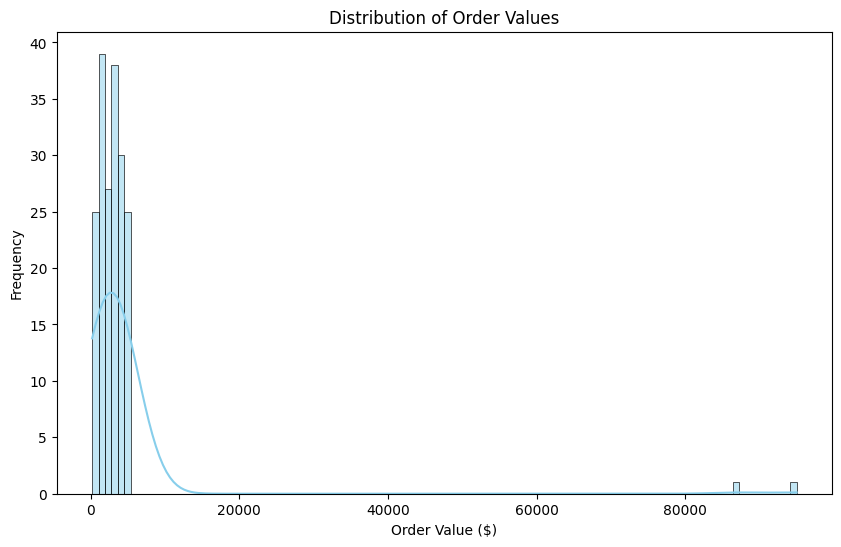

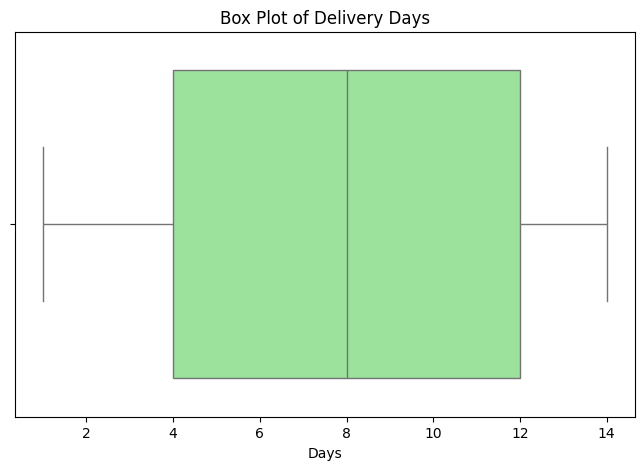

In [4]:
# Histogram for order_value
plt.figure(figsize=(10, 6))
sns.histplot(df['order_value'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Order Values')
plt.xlabel('Order Value ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot for delivery_days
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['delivery_days'], color='lightgreen')
plt.title('Box Plot of Delivery Days')
plt.xlabel('Days')
plt.show()

Task 3: Correlation Analysis

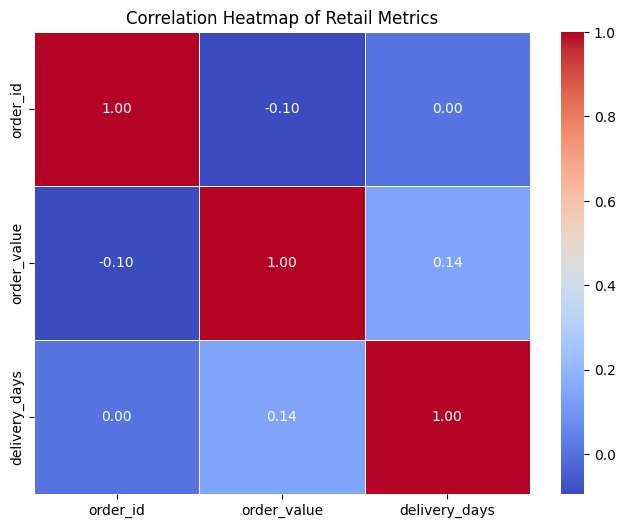

In [5]:
# Compute Correlation Matrix (Numeric Only)
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Retail Metrics')
plt.show()

Markdown Observation:
* Relationship Identified: There is a very weak/near-zero correlation between order_value and delivery_days. This suggests that the price of an item in this dataset does not significantly influence how quickly it is delivered.